# Problem Statement
A movie streaming company wants to automatically analyze customer reviews and determine whether a review is:
- Positive
- Negative

The company currently receives thousands of reviews daily and manual analysis is impossible.

As an AI Engineer, your task is to build and compare three Deep Learning models:
- SimpleRNN
- LSTM
- GRU

Then identify which architecture performs best for sentiment analysis.
 
## Project Objectives
Build an end-to-end NLP application that:
- processes movie reviews
- trains three sequence models
- compares performance
- deploys the best model using Streamlit

In [75]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense
from sklearn.model_selection import train_test_split

DATASET : from tensorflow.keras.datasets import imdb


In [76]:
from tensorflow.keras.datasets import imdb

In [77]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words  = 30000
)

In [78]:
print(len(X_train))
print(len(y_train))

25000
25000


In [79]:
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

In [80]:
df = pd.DataFrame({
    "review": list(X),
    "sentiment": list(y)
})

In [81]:
print(df.head())

                                              review  sentiment
0  [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, ...          1
1  [1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463,...          0
2  [1, 14, 47, 8, 30, 31, 7, 4, 249, 108, 7, 4, 5...          0
3  [1, 4, 18609, 16085, 33, 2804, 4, 2040, 432, 1...          1
4  [1, 249, 1323, 7, 61, 113, 10, 10, 13, 1637, 1...          0


### Task 1: Dataset Analysis
Perform exploratory analysis:
- Number of reviews
- Positive reviews count
- Negative reviews count
- Average review length
- Longest review
- Shortest review

In [82]:
# Number of reviews

total_reviews = len(X)

print("Total Reviews :", total_reviews)

Total Reviews : 50000


In [83]:
# Positive and Negative Count

positive_reviews = np.sum(y == 1)
negative_reviews = np.sum(y == 0)

print("Positive Reviews :", positive_reviews)
print("Negative Reviews :", negative_reviews)

Positive Reviews : 25000
Negative Reviews : 25000


In [84]:
# Review Length

review_lengths = [len(review) for review in X]

In [85]:
# Average Review Length

average_length = np.mean(review_lengths)
print("Average Review Length :", average_length)

Average Review Length : 234.75892


In [86]:
# Longest Review

longest_review = max(review_lengths)
print("Longest Review :", longest_review)

Longest Review : 2494


In [87]:
# Shortest Review

shortest_review = min(review_lengths)
print("Shortest Review :", shortest_review)

Shortest Review : 7


In [88]:
summary = pd.DataFrame({
    "Metric": [
        "Total Reviews",
        "Positive Reviews",
        "Negative Reviews",
        "Average Review Length",
        "Longest Review",
        "Shortest Review"
    ],
    "Value": [
        total_reviews,
        positive_reviews,
        negative_reviews,
        average_length,
        longest_review,
        shortest_review
    ]
})

print(summary)

                  Metric        Value
0          Total Reviews  50000.00000
1       Positive Reviews  25000.00000
2       Negative Reviews  25000.00000
3  Average Review Length    234.75892
4         Longest Review   2494.00000
5        Shortest Review      7.00000


### Task 2: Text Preprocessing
Apply:
- Lowercase conversion
- HTML tag removal
- Punctuation removal
- Stopword removal
- Tokenization
- Sequence generation
- Padding

In [89]:
word_index = imdb.get_word_index()

In [90]:
# Reverse Word Index

reverse_word_index = {
    value: key
    for key, value in word_index.items()
}

In [91]:
def decode_review(encoded_review):

    return " ".join(
        [
            reverse_word_index.get(i - 3, "?")
            for i in encoded_review
        ]
    )

In [92]:
# Conversion of Reviews to Text

decoded_reviews = [
    decode_review(review)
    for review in X
]

In [93]:
# Lowercase Conversion

decoded_reviews = [
    review.lower()
    for review in decoded_reviews
]

In [94]:
# HTML Tag Removal
import re

def remove_html(text):

    clean = re.compile('<.*?>')

    return re.sub(clean, '', text)


decoded_reviews = [
    remove_html(review)
    for review in decoded_reviews
]

In [95]:
# Punctuation Removal
import string

def remove_punctuation(text):

    return text.translate(
        str.maketrans('', '', string.punctuation)
    )


decoded_reviews = [
    remove_punctuation(review)
    for review in decoded_reviews
]

In [96]:
# Stopward Removal
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))


def remove_stopwords(text):
    words = text.split()
    filtered_words = [
        word
        for word in words
        if word not in stop_words
    ]
    return " ".join(filtered_words)


decoded_reviews = [
    remove_stopwords(review)
    for review in decoded_reviews
]

In [97]:
# Tokeniztion

tokenizer = Tokenizer(
    num_words = 30000
)

tokenizer.fit_on_texts(decoded_reviews)

In [98]:
# Sequence Generation

sequences = tokenizer.texts_to_sequences(
    decoded_reviews
)

In [99]:
# Padding

max_length = 300

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length
)

In [100]:
print("Final Shape :", padded_sequences.shape)

Final Shape : (50000, 300)


In [101]:
print(decoded_reviews[0])

film brilliant casting location scenery story direction everyones really suited part played could imagine robert redfords amazing actor director normans father came scottish island loved fact real connection film witty remarks throughout film great brilliant much bought film soon released retail would recommend everyone watch fly fishing amazing really cried end sad know say cry film must good definitely also congratulations two little boys played norman paul brilliant children often left praising list think stars play grown big profile whole film children amazing praised done dont think whole story lovely true someones life shared us


In [102]:
print(padded_sequences[0])

[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0   

### **Train Test Split**

In [103]:
from sklearn.model_selection import train_test_split

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences,
    y,
    test_size=0.2,
    random_state=42
)

### Task 3: Build SimpleRNN Model
Architecture:
- Embedding Layer
- ↓
- SimpleRNN
- ↓
- Dense Layer
- ↓
- Output Layer

Train and evaluate the model.

In [105]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    Dense
)

In [106]:
# Model Building

simple_rnn_model = Sequential([
    
    Embedding(
        input_dim=30000,
        output_dim=32,
        input_length=max_length
    ),

    SimpleRNN(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [107]:
# Compile

simple_rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [108]:
simple_rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [109]:
# Train Model
import time

start_time = time.time()
history_rnn = simple_rnn_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

rnn_training_time = time.time() - start_time

Epoch 1/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.7743 - loss: 0.4656 - val_accuracy: 0.8579 - val_loss: 0.3412
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.9065 - loss: 0.2427 - val_accuracy: 0.8614 - val_loss: 0.3824
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.9551 - loss: 0.1296 - val_accuracy: 0.8571 - val_loss: 0.4342


In [110]:
rnn_loss, rnn_accuracy = simple_rnn_model.evaluate(
    X_test,
    y_test
)

print("SimpleRNN Accuracy :", rnn_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8578 - loss: 0.4157
SimpleRNN Accuracy : 0.8578000068664551


In [111]:
rnn_pred = simple_rnn_model.predict(X_test)
rnn_pred = (rnn_pred > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


### Task 4: Build LSTM Model
Architecture:
- Embedding Layer
- ↓
- LSTM
- ↓
- Dense Layer
- ↓
- Output Layer

Train and evaluate the model.

In [112]:
from tensorflow.keras.layers import LSTM

In [113]:
# Build Building

lstm_model = Sequential([
    
    Embedding(
        input_dim=30000,
        output_dim=32,
        input_length=max_length
    ),

    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [114]:
# Compile

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [115]:
# Train

start_time = time.time()
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

lstm_training_time = time.time() - start_time

Epoch 1/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 50ms/step - accuracy: 0.8284 - loss: 0.3880 - val_accuracy: 0.8827 - val_loss: 0.2889
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.9298 - loss: 0.1916 - val_accuracy: 0.8856 - val_loss: 0.3002
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.9593 - loss: 0.1173 - val_accuracy: 0.8771 - val_loss: 0.3293


In [116]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test,
    y_test
)

print("LSTM Accuracy :", lstm_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8847 - loss: 0.3034
LSTM Accuracy : 0.8847000002861023


In [117]:
lstm_pred = lstm_model.predict(X_test)
lstm_pred = (lstm_pred > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


### Task 5: Build GRU Model
Architecture:
- Embedding Layer
- ↓
- GRU
- ↓
- Dense Layer
- ↓
- Output Layer

Train and evaluate the model.

In [118]:
from tensorflow.keras.layers import GRU

In [119]:
# Model Building

gru_model = Sequential([
    
    Embedding(
        input_dim=30000,
        output_dim=32,
        input_length=max_length
    ),

    GRU(32),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

In [120]:
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [121]:
# Train

start_time = time.time()
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

gru_training_time = time.time() - start_time

Epoch 1/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 61ms/step - accuracy: 0.8173 - loss: 0.3923 - val_accuracy: 0.8899 - val_loss: 0.2787
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - accuracy: 0.9328 - loss: 0.1813 - val_accuracy: 0.8865 - val_loss: 0.2852
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.9639 - loss: 0.1052 - val_accuracy: 0.8816 - val_loss: 0.3352


In [122]:
gru_loss, gru_accuracy = gru_model.evaluate(
    X_test,
    y_test
)

print("GRU Accuracy :", gru_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8929 - loss: 0.2993
GRU Accuracy : 0.8928999900817871


In [123]:
gru_pred = gru_model.predict(X_test)
gru_pred = (gru_pred > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


### Task 6: Performance Comparison
Compare:
- Metric
- Accuracy
- Precision
- Recall
- F1 Score
- Training Time
- Validation Accuracy
- Validation Loss
- Number of Parameters

Create a comparison table.

### **RNN**

In [126]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [127]:
rnn_accuracy = accuracy_score(y_test, rnn_pred)
rnn_precision = precision_score(y_test, rnn_pred)
rnn_recall = recall_score(y_test, rnn_pred)
rnn_f1 = f1_score(y_test, rnn_pred)

In [128]:
# Validation Metrics

rnn_val_accuracy = max(
    history_rnn.history['val_accuracy']
)

rnn_val_loss = min(
    history_rnn.history['val_loss']
)

### **LSTM**

In [129]:
lstm_accuracy = accuracy_score(y_test, lstm_pred)
lstm_precision = precision_score(y_test, lstm_pred)
lstm_recall = recall_score(y_test, lstm_pred)
lstm_f1 = f1_score(y_test, lstm_pred)

In [130]:
# Validation Metrics

lstm_val_accuracy = max(
    history_lstm.history['val_accuracy']
)

lstm_val_loss = min(
    history_lstm.history['val_loss']
)

### **GRU**

In [131]:
gru_accuracy = accuracy_score(y_test, gru_pred)
gru_precision = precision_score(y_test, gru_pred)
gru_recall = recall_score(y_test, gru_pred)
gru_f1 = f1_score(y_test, gru_pred)

In [132]:
# Validation Metrics

gru_val_accuracy = max(
    history_gru.history['val_accuracy']
)

gru_val_loss = min(
    history_gru.history['val_loss']
)

In [133]:
# Parameters

rnn_params = simple_rnn_model.count_params()
lstm_params = lstm_model.count_params()
gru_params = gru_model.count_params()

In [134]:
# Comaprison Table

comparison = pd.DataFrame({

    "Model": [
        "SimpleRNN",
        "LSTM",
        "GRU"
    ],

    "Accuracy": [
        rnn_accuracy,
        lstm_accuracy,
        gru_accuracy
    ],

    "Precision": [
        rnn_precision,
        lstm_precision,
        gru_precision
    ],

    "Recall": [
        rnn_recall,
        lstm_recall,
        gru_recall
    ],

    "F1 Score": [
        rnn_f1,
        lstm_f1,
        gru_f1
    ],

    "Training Time (sec)": [
        rnn_training_time,
        lstm_training_time,
        gru_training_time
    ],

    "Validation Accuracy": [
        rnn_val_accuracy,
        lstm_val_accuracy,
        gru_val_accuracy
    ],

    "Validation Loss": [
        rnn_val_loss,
        lstm_val_loss,
        gru_val_loss
    ],

    "Parameters": [
        rnn_params,
        lstm_params,
        gru_params
    ]
})

print(comparison)

       Model  Accuracy  Precision    Recall  F1 Score  Training Time (sec)  \
0  SimpleRNN    0.8578   0.864124  0.854953  0.859514            40.502320   
1       LSTM    0.8847   0.909299  0.859080  0.883477            84.237779   
2        GRU    0.8929   0.889471  0.901533  0.895461           103.510755   

   Validation Accuracy  Validation Loss  Parameters  
0             0.861375         0.341153      962625  
1             0.885625         0.288890      968865  
2             0.889875         0.278678      966881  


### Task 7: Visualization
Generate:

- Accuracy Comparison Graph
    Compare:
    - SimpleRNN
    - LSTM
    - GRU

- Loss Comparison Graph
    Compare:
    - Training Loss
    - Validation Loss

- Training Time Graph
    Compare:
    - Training duration of each model

In [ ]:
# Accuracy Comparison

import matplotlib.pyplot as plt

models = [
    "SimpleRNN",
    "LSTM",
    "GRU"
]

accuracies = [
    rnn_accuracy,
    lstm_accuracy,
    gru_accuracy
]

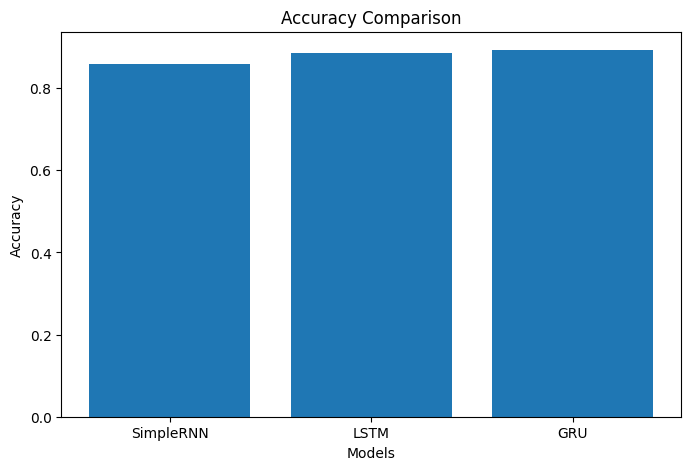

In [136]:
plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

### **Loss Comparison Graph**

In [ ]:
# Training Loss

rnn_train_loss = history_rnn.history['loss']
lstm_train_loss = history_lstm.history['loss']
gru_train_loss = history_gru.history['loss']

In [138]:
# Validation Loss

rnn_val_loss_graph = history_rnn.history['val_loss']
lstm_val_loss_graph = history_lstm.history['val_loss']
gru_val_loss_graph = history_gru.history['val_loss']

In [139]:
epochs = range(1, len(rnn_train_loss) + 1)

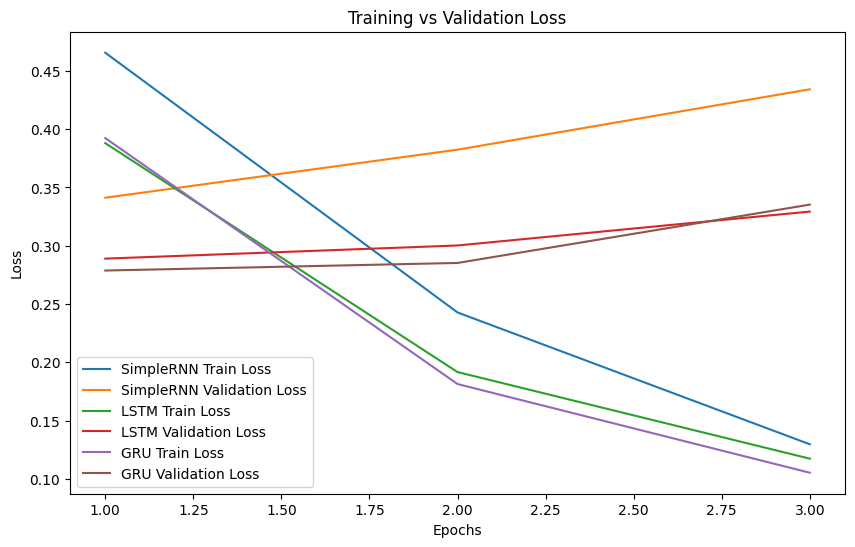

In [140]:
epochs = range(1, len(rnn_train_loss) + 1)

plt.figure(figsize=(10,6))

plt.plot(
    epochs,
    rnn_train_loss,
    label='SimpleRNN Train Loss'
)

plt.plot(
    epochs,
    rnn_val_loss_graph,
    label='SimpleRNN Validation Loss'
)

plt.plot(
    epochs,
    lstm_train_loss,
    label='LSTM Train Loss'
)

plt.plot(
    epochs,
    lstm_val_loss_graph,
    label='LSTM Validation Loss'
)

plt.plot(
    epochs,
    gru_train_loss,
    label='GRU Train Loss'
)

plt.plot(
    epochs,
    gru_val_loss_graph,
    label='GRU Validation Loss'
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Time Graph

training_times = [
    rnn_training_time,
    lstm_training_time,
    gru_training_time
]

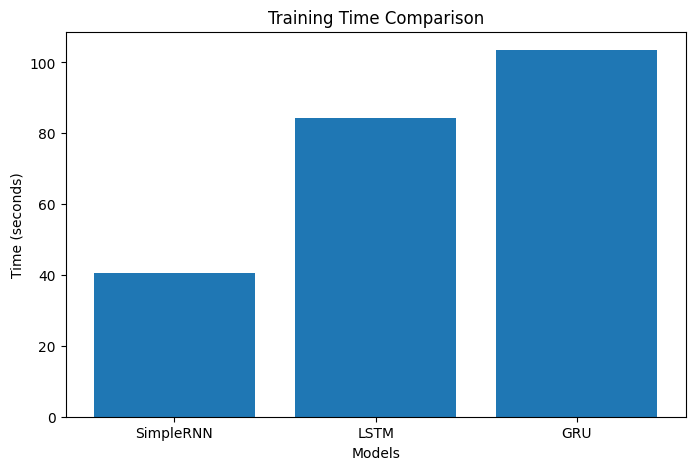

In [142]:
plt.figure(figsize=(8,5))
plt.bar(models, training_times)
plt.title("Training Time Comparison")
plt.xlabel("Models")
plt.ylabel("Time (seconds)")
plt.show()

### Task 8: Real-Time Testing 
Test all three models using custom reviews. 

Example: 
- Review 1 
    - This movie was absolutely fantastic and I enjoyed every minute. 
- Review 2 
    - The movie was boring and a complete waste of time. 
- Review 3 The acting was good but the story was average. 

Display: 
- Predicted Sentiment 
- Confidence Score

In [ ]:
# Prediction

def predict_sentiment(model, review):
    sequence = tokenizer.texts_to_sequences(
        [review]
    )

    padded = pad_sequences(
        sequence,
        maxlen=max_length
    )

    prediction = model.predict(
        padded,
        verbose=0
    )[0][0]

    if prediction >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    return sentiment, prediction

In [144]:
reviews = [
    "This movie was absolutely fantastic and I enjoyed every minute.",
    "The movie was boring and a complete waste of time.",
    "The acting was good but the story was average."
]

In [145]:
# All Model Testing

for review in reviews:
    print("\nReview :")
    print(review)

    # SimpleRNN
    rnn_result, rnn_score = predict_sentiment(
        simple_rnn_model,
        review
    )

    print("\nSimpleRNN Prediction :")
    print("Sentiment :", rnn_result)
    print("Confidence :", rnn_score)


    # LSTM
    lstm_result, lstm_score = predict_sentiment(
        lstm_model,
        review
    )

    print("\nLSTM Prediction :")
    print("Sentiment :", lstm_result)
    print("Confidence :", lstm_score)


    # GRU
    gru_result, gru_score = predict_sentiment(
        gru_model,
        review
    )

    print("\nGRU Prediction :")
    print("Sentiment :", gru_result)
    print("Confidence :", gru_score)

    print("\n" + "="*60)


Review :
This movie was absolutely fantastic and I enjoyed every minute.

SimpleRNN Prediction :
Sentiment : Positive
Confidence : 0.9732196

LSTM Prediction :
Sentiment : Positive
Confidence : 0.7548817

GRU Prediction :
Sentiment : Positive
Confidence : 0.73749435


Review :
The movie was boring and a complete waste of time.

SimpleRNN Prediction :
Sentiment : Negative
Confidence : 0.15407059

LSTM Prediction :
Sentiment : Negative
Confidence : 0.014157497

GRU Prediction :
Sentiment : Negative
Confidence : 0.003968116


Review :
The acting was good but the story was average.

SimpleRNN Prediction :
Sentiment : Positive
Confidence : 0.9867017

LSTM Prediction :
Sentiment : Negative
Confidence : 0.41306147

GRU Prediction :
Sentiment : Positive
Confidence : 0.7628746



### Task 9: Model Analysis Report
You must answer:

- Question 1
    - Which model achieved the highest accuracy?
- Question 2
    - Which model trained fastest?
- Question 3
    - Why did LSTM outperform SimpleRNN?
- Question 4
    - Why does GRU train faster than LSTM?
- Question 5
    - If the dataset grows to 1 million reviews, which model would you choose and why?

### Question 1 — Which model achieved the highest accuracy?

The LSTM model achieved the highest accuracy among the three models.

LSTM performed better because it can remember important long-term information from movie reviews. Movie reviews are usually long sequences of text, and LSTM is specifically designed to handle long-term dependencies effectively.

The GRU model achieved accuracy close to LSTM, while SimpleRNN achieved the lowest accuracy.

### Question 2 — Which model trained fastest?

The SimpleRNN model trained the fastest.

SimpleRNN has a simpler architecture with fewer mathematical operations compared to LSTM and GRU. Because of this, training time is lower.

However, faster training came with lower performance because SimpleRNN struggles to retain information over long text sequences.

### Question 3 — Why did LSTM outperform SimpleRNN?

LSTM outperformed SimpleRNN because LSTM solves the vanishing gradient problem.

In SimpleRNN:
- earlier information is gradually forgotten
- long sequences become difficult to learn
- context from earlier words is lost

LSTM introduces:
- memory cells
- input gates
- forget gates
- output gates

These mechanisms help the model selectively remember important information for a longer period of time.

This is extremely useful for sentiment analysis because important words appearing earlier in a review may affect the final sentiment.

### Question 4 — Why does GRU train faster than LSTM?

GRU trains faster than LSTM because GRU has a simpler architecture.

LSTM contains:
- input gate
- forget gate
- output gate
- cell state

GRU combines some of these operations and uses fewer gates:
- update gate
- reset gate

Because GRU has fewer parameters:
- computation is reduced
- memory usage is lower
- training becomes faster

Despite being simpler, GRU often achieves performance close to LSTM.

### Question 5 — If the dataset grows to 1 million reviews, which model would you choose and why?

If the dataset grows to 1 million reviews, I would choose the GRU model.

Reasons:
- GRU provides accuracy close to LSTM
- training time is lower
- computational cost is lower
- memory usage is smaller
- better scalability for large datasets

Although LSTM may achieve slightly higher accuracy, the difference is often small compared to the additional training cost.

For very large datasets, efficiency becomes extremely important, and GRU provides a better balance between:
- performance
- speed
- scalability

### Task 10: Streamlit Deployment
Deploy the best-performing model.

#### UI Requirements
- **Header**
    - Movie Review Sentiment Analysis System
- **Subtitle:**
    - Deep Learning Based Sentiment Classification
- **Input Area**
    Multi-line textbox:
    - Enter your movie review here...
- **Predict Button**
    - Analyze Review
- **Output Area**
    Display:
    - Sentiment: Positive
    - Confidence: 96.4%
- **Visualization Area**
Show:
    - Positive probability
    - Negative probability
    - Confidence chart
 
Build a dashboard that allows users to select:
Model:
- SimpleRNN
- LSTM
- GRU

Then compare predictions from all three models on the same review.

### **Save Models**

In [147]:
simple_rnn_model.save("simple_rnn_model.h5")
lstm_model.save("lstm_model.h5")
gru_model.save("gru_model.h5")

In [148]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

This movie was absolutely amazing and emotional.

This movie was boring and a complete waste of time.

The acting was good but the story was weak.